In [45]:
from google.cloud import bigquery

import numpy as np

import matplotlib.pyplot as plt
import igraph as ig

import csv
from math import floor

In [18]:
client = bigquery.Client(project='gcp-cset-projects')

In [19]:
layout = []
with open("layouts/clust_locations.csv", mode='r') as f:
    csvfil = csv.DictReader(f)
    for line in csvfil:
        layout.append(line)

In [20]:
cluster_size_query = """
SELECT
  cluster_id,
  COUNT(family_id) AS size
FROM staging_patent_clusters.cluster_assignment
GROUP BY cluster_id
ORDER BY cluster_id
"""
result = client.query(cluster_size_query)
cluster_sizes = []
for row in result:
    temp_dict = {'cluster_id':row['cluster_id'],'size':row['size']}
    cluster_sizes.append(temp_dict)

max_size = max([r['size'] for r in cluster_sizes])
max_cluster_id = max([r['cluster_id'] for r in cluster_sizes])
vertex_sizes = [0 for i in range(max_cluster_id+1)]
for row in cluster_sizes:
    vertex_sizes[row['cluster_id']] = np.sqrt(row['size']/max_size)
vertex_sizes = np.array(vertex_sizes)

In [106]:
cluster_category_query = """
WITH
family_categories AS (
  SELECT
    DISTINCT
    family_id,
    cluster_id,
    technology_category AS category
  FROM staging_patent_clusters.cluster_assignment
  LEFT JOIN patent_categories.categories USING(family_id)
  WHERE cluster_id IS NOT NULL
),
cluster_categories AS (
  SELECT
    DISTINCT
    cluster_id,
    category,
    COUNT(*) AS n_patents
  FROM family_categories
  GROUP BY cluster_id, category
),
cluster_categories_ranking AS (
  SELECT
    DISTINCT
    cluster_id,
    category,
    n_patents,
    ROW_NUMBER() OVER (PARTITION BY cluster_id ORDER BY n_patents DESC) AS cat_rank
  FROM cluster_categories
)

SELECT
  cluster_id,
  category
FROM cluster_categories_ranking
WHERE cat_rank = 1
ORDER BY cluster_id
"""

result = client.query(cluster_category_query)
cluster_categories = []
for row in result:
    temp_dict = {'cluster_id':row['cluster_id'],'category':row['category']}
    cluster_categories.append(temp_dict)

In [111]:
category_query = """
SELECT
  DISTINCT
  technology_category AS category
FROM patent_categories.categories
ORDER BY category
"""

result = client.query(category_query)
categories = {None:np.array([0,0,0])}
for row in result:
    #temp_dict = {'category':row['category']}
    #categories.append(temp_dict)
    categories[row['category']] = np.array(np.random.choice(range(256), size=3))

In [113]:
cluster_colors = [categories[r['category']]/256 for r in cluster_categories]

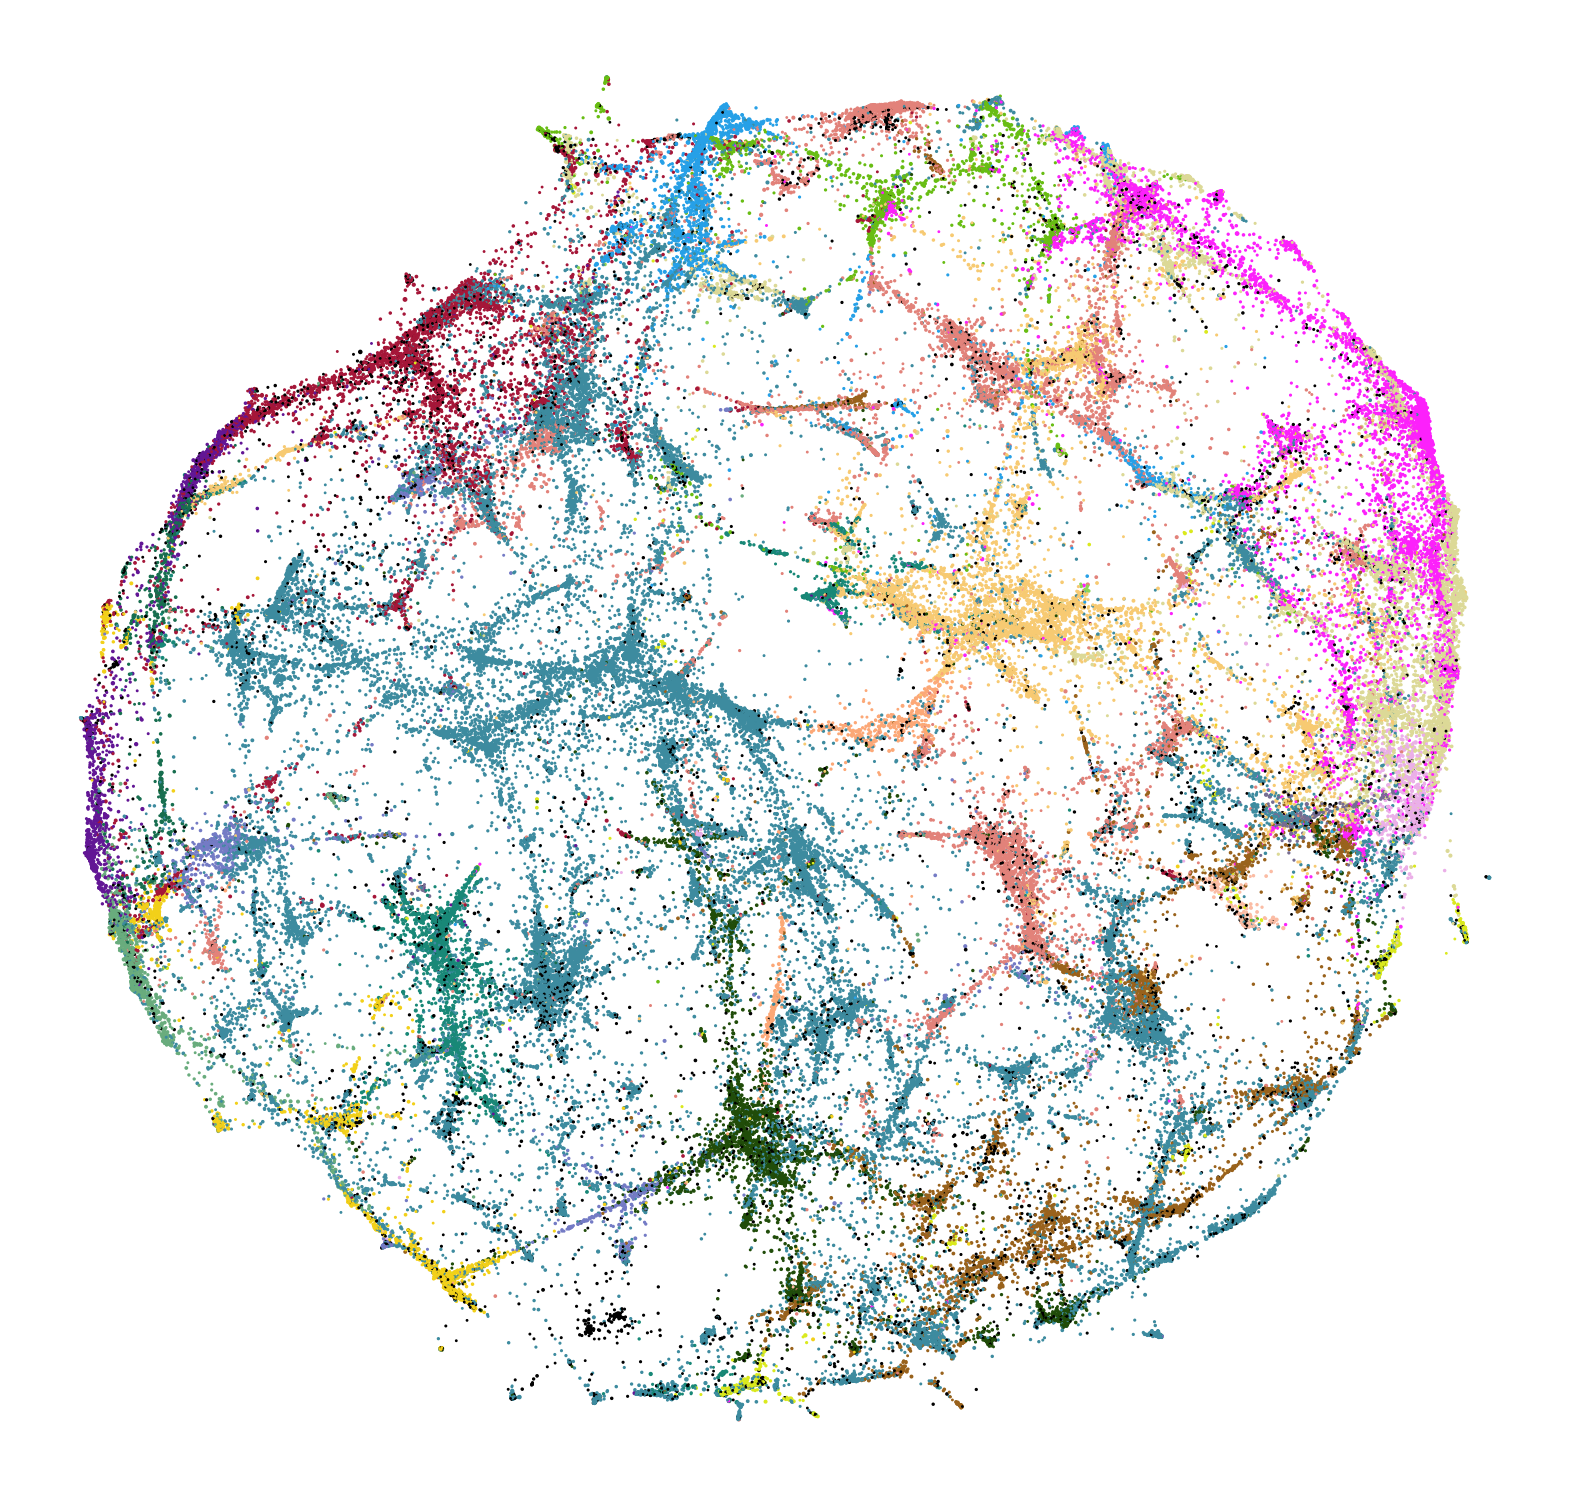

In [114]:
fig, ax = plt.subplots(figsize=(20,20))
x = np.array([float(r['x']) for r in layout])
y = np.array([float(r['y']) for r in layout])
n_clusters = len(x)
plt.scatter(x[0:n_clusters],y[0:n_clusters], s = 10*vertex_sizes[0:n_clusters], c=cluster_colors[0:n_clusters])
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])
plt.show()

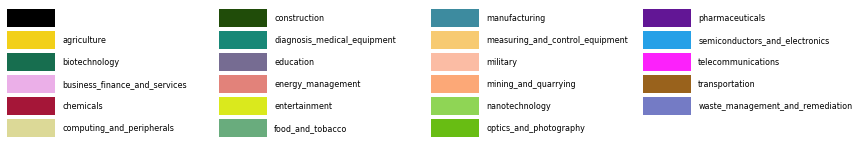

In [115]:
cell_width = 212
cell_height = 22
swatch_width = 48
margin = 12
topmargin = 40
emptycols = 0

# Sort colors by hue, saturation, value and name.
names = list(categories.keys())

n = len(names)
ncols = 4 - emptycols
nrows = n // ncols + int(n % ncols > 0)

width = cell_width * 4 + 2 * margin
height = cell_height * nrows + margin + topmargin
dpi = 72

fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
fig.subplots_adjust(margin/width, margin/height,
                    (width-margin)/width, (height-topmargin)/height)
ax.set_xlim(0, cell_width * 4)
ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
ax.yaxis.set_visible(False)
ax.xaxis.set_visible(False)
ax.set_axis_off()
#ax.set_title(title, fontsize=24, loc="left", pad=10)

for i, name in enumerate(names):
    row = i % nrows
    col = i // nrows
    y = row * cell_height

    swatch_start_x = cell_width * col
    swatch_end_x = cell_width * col + swatch_width
    text_pos_x = cell_width * col + swatch_width + 7

    ax.text(text_pos_x, y, name, fontsize=8,
            horizontalalignment='left',
            verticalalignment='center')

    ax.hlines(y, swatch_start_x, swatch_end_x,
              color=categories[name]/256, linewidth=18)
